In [33]:
import pandas as pd

reviews = pd.read_csv('steam_reviews.csv')
reviews.head()

,app_id,game_name,players_2weeks,average_2weeks,ccu,recommendationid,language,review,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,timestamp_created
0,730,Counter-Strike: Global Offensive,NaN,0,1013936,234359556,koreana,이 게임을 하고 나서 내 자존감이 높아졌다\n인성 터진 개쓰레기들을 만나면서 와 나...,True,165,45,0.939227,0,True,False,False,1788421673
1,730,Counter-Strike: Global Offensive,NaN,0,1013936,233719675,schinese,我爱这个游戏，100%，但很多时候爱不能支撑着我们走下去。\n诚然，我才玩了一千多个小时，对...,False,114,10,0.857527,0,True,False,False,1787719974
2,730,Counter-Strike: Global Offensive,NaN,0,1013936,233663687,turkish,yeter artık ota boka güncelleme getirmeyin her...,False,96,17,0.851472,1,True,False,False,1787661449
3,730,Counter-Strike: Global Offensive,NaN,0,1013936,233620085,brazilian,"7.500,00 horas jogadas deve significar algo pa...",True,64,3,0.847348,7,True,False,False,1787603946
4,730,Counter-Strike: Global Offensive,NaN,0,1013936,234377029,russian,"Есть ощущение, что игра поощряет использование...",False,88,2,0.846272,4,True,False,False,1788444662


In [34]:
eng_reviews = reviews[reviews['language'] == 'english']
eng_reviews.head()

,app_id,game_name,players_2weeks,average_2weeks,ccu,recommendationid,language,review,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,timestamp_created
5,730,Counter-Strike: Global Offensive,NaN,0,1013936,234086909,english,cheater's don't even try to hide that they are...,False,106,2,0.842034,13,True,False,False,1788103072
7,730,Counter-Strike: Global Offensive,NaN,0,1013936,233905295,english,"Great game, amazing gunplay, but here is a Bro...",True,977,164,0.807750,12,True,False,False,1787926248
8,730,Counter-Strike: Global Offensive,NaN,0,1013936,234924603,english,"Yes bro nice game, almost broke my monitor😊😊😊😊...",True,76,51,0.785768,8,True,False,False,1789058855
10,730,Counter-Strike: Global Offensive,NaN,0,1013936,234645373,english,DO NOT PLAY THIS GAME - CHEATERS SIMULATOR 2\r...,False,35,1,0.781439,12,True,False,False,1788721972
15,730,Counter-Strike: Global Offensive,NaN,0,1013936,234147368,english,"Gambling, hackers, a constant influx of ♥♥♥♥♥♥...",True,493,22,0.745693,6,True,False,False,1788165943


In [35]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
eng_reviews = eng_reviews.copy()
eng_reviews['review'] = eng_reviews['review'].fillna('').astype(str)
eng_reviews['sentiment_score'] = eng_reviews['review'].apply(
    lambda review: analyzer.polarity_scores(review)['compound']
)

print(eng_reviews[['review', 'sentiment_score']])

                                                review  sentiment_score
5    cheater's don't even try to hide that they are...          -0.6020
7    Great game, amazing gunplay, but here is a Bro...           0.9476
8    Yes bro nice game, almost broke my monitor😊😊😊😊...           0.9981
10   DO NOT PLAY THIS GAME - CHEATERS SIMULATOR 2\r...           0.9803
15   Gambling, hackers, a constant influx of ♥♥♥♥♥♥...           0.9880
..                                                 ...              ...
906  The game is good especially with other people ...           0.7184
907  I literally cant stop bouncing everytime I boo...          -0.7279
909  still to this day. nothing comes close to this...           0.9349
912  this might genuinely be the worst zombie game ...          -0.8001
913  really good game. not a bot comment. just an o...           0.7264

[391 rows x 2 columns]


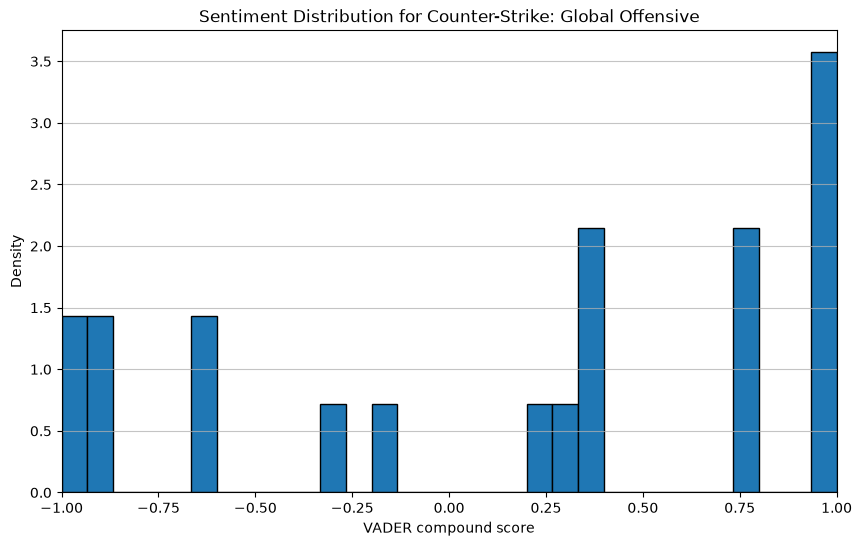

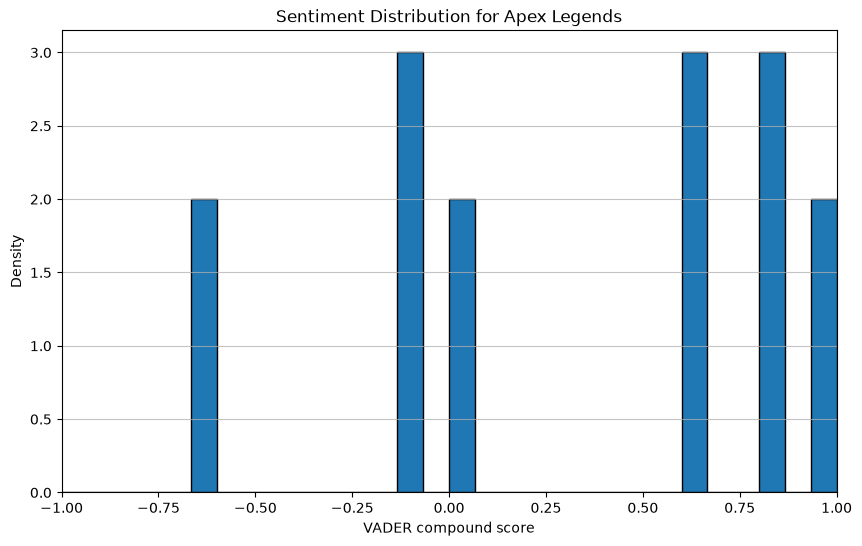

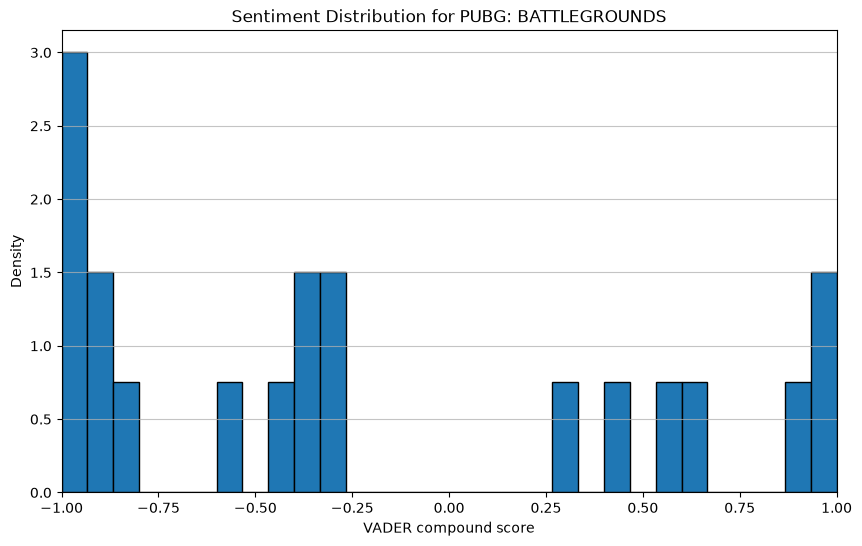

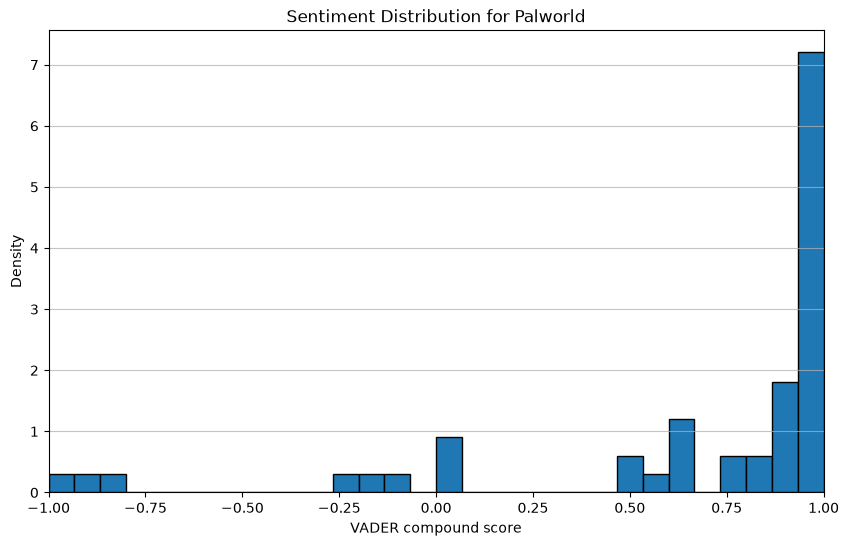

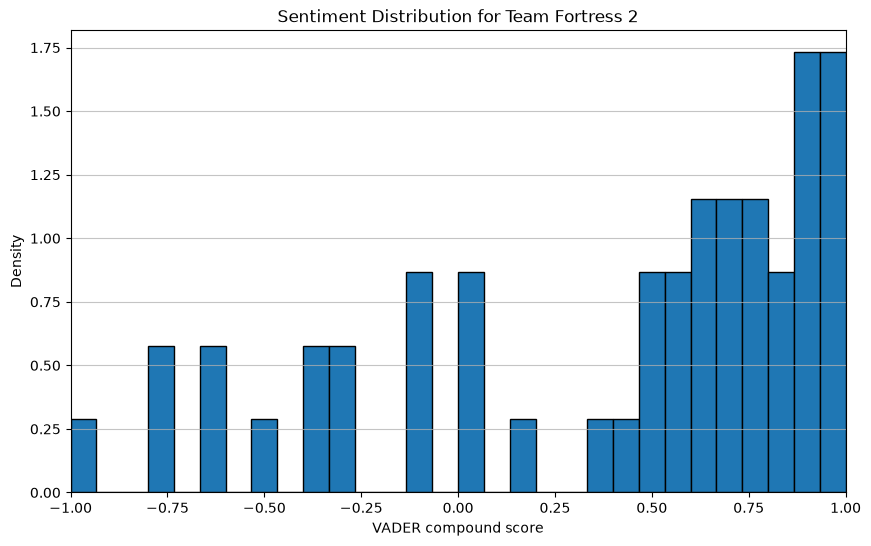

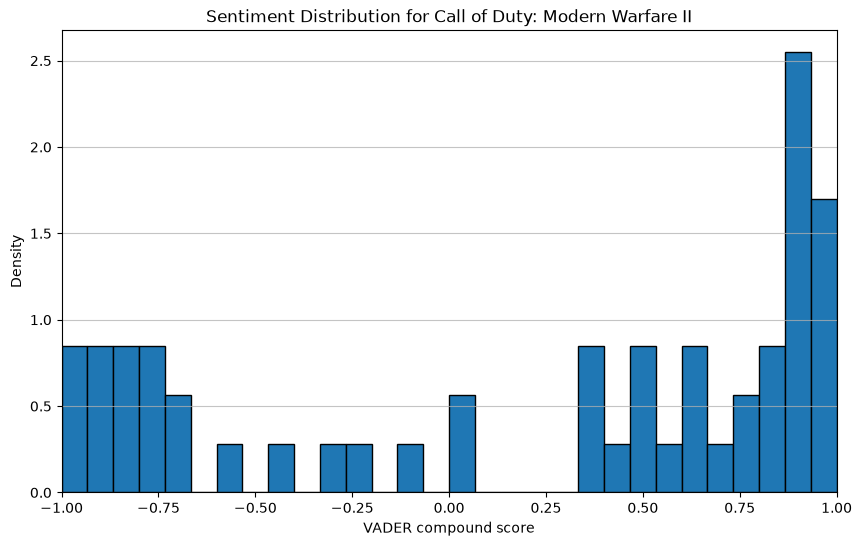

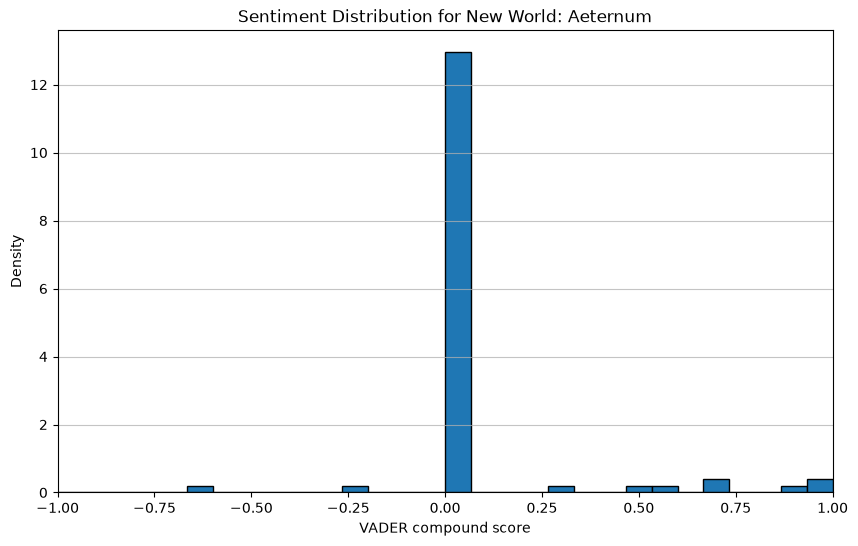

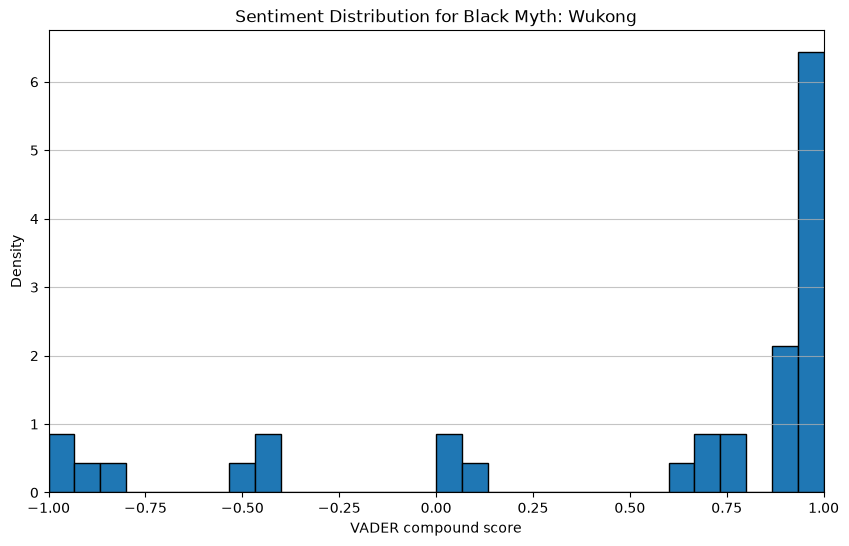

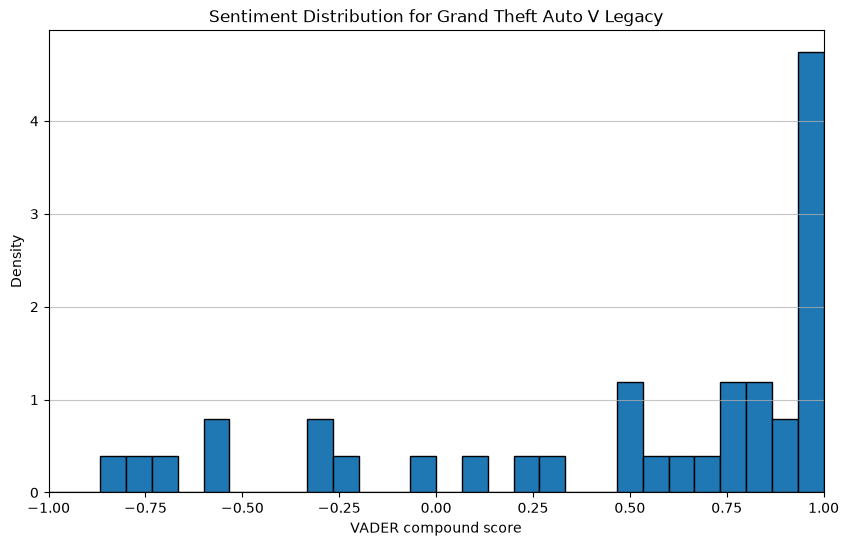

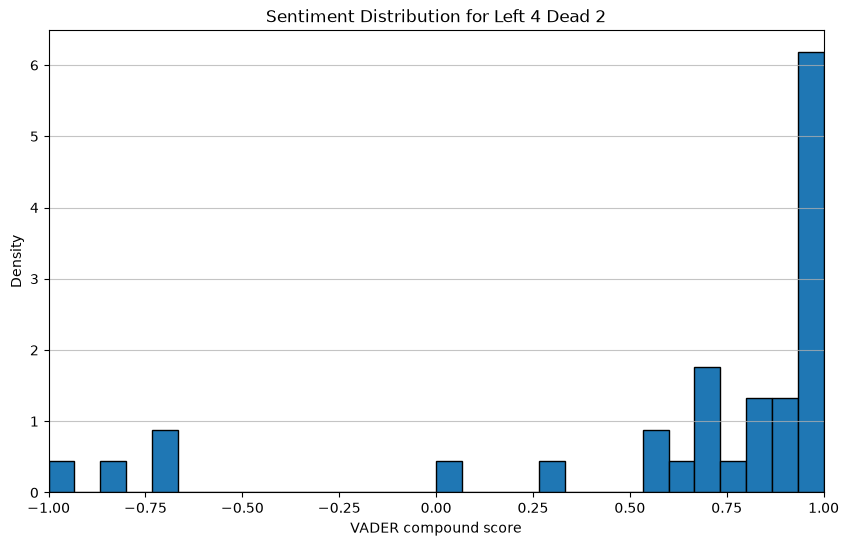

In [38]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(-1, 1, 31)

for appid in appids:
    game_reviews = eng_reviews[eng_reviews["app_id"] == appid]
    game = game_reviews.iloc[0]["game_name"]

    plt.figure(figsize=(10, 6))
    plt.hist(
        game_reviews["sentiment_score"],
        bins=bins,
        density=True,
        edgecolor="black"
    )
    plt.xlim(-1, 1)
    plt.title(f"Sentiment Distribution for {game}")
    plt.xlabel("VADER compound score")
    plt.ylabel("Density")
    plt.grid(axis="y", alpha=0.75)
    plt.show()

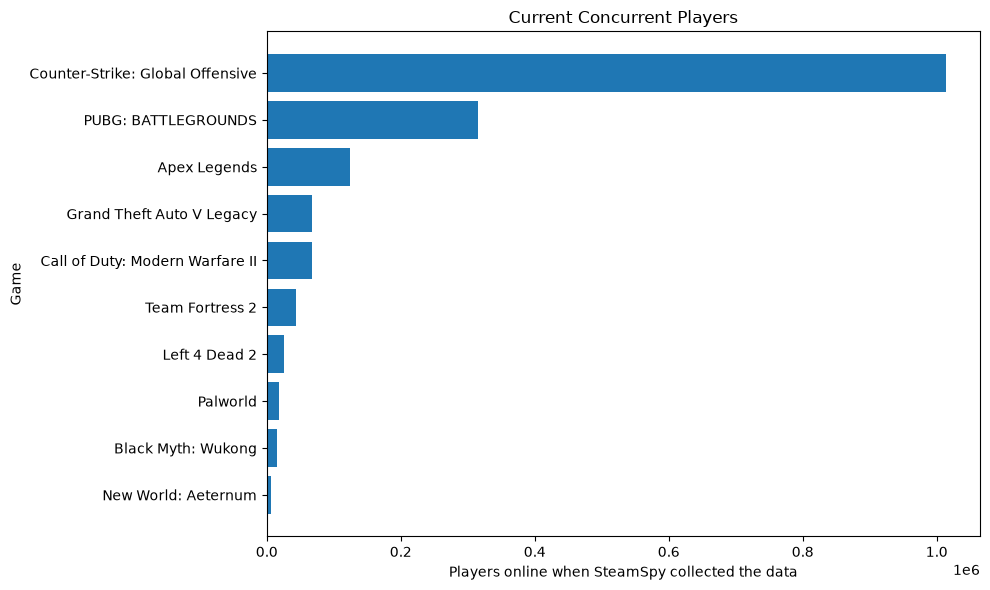

In [37]:
import matplotlib.pyplot as plt

player_counts = (
    eng_reviews[['app_id', 'game_name', 'ccu']]
    .drop_duplicates('app_id')
    .assign(ccu=lambda frame: pd.to_numeric(frame['ccu'], errors='coerce'))
    .dropna(subset=['ccu'])
    .query('ccu > 0')
    .sort_values('ccu')
)

plt.figure(figsize=(10, 6))
plt.barh(player_counts['game_name'], player_counts['ccu'])
plt.title('Current Concurrent Players')
plt.xlabel('Players online when SteamSpy collected the data')
plt.ylabel('Game')
plt.tight_layout()
plt.show()